## Storytelling graphs

In [5]:
import pandas as pd
import duckdb
import matplotlib
from charts_utils import billions_formatter, millions_formatter
from constants import GRAY_1, GRAY_2, GRAY_3, BLUE_1


In [6]:
df = pd.read_csv("IT-Help-clean.csv")
df.head()

,Unnamed: 0,ticket,requestor,ITOwner,FiledAgainst,TicketType,daysOpen,Priority,Satisfation,Severity,RequestorSeniority
0,0,1,1929,50,Systems,Issue,3,Unassigned,Unsatisfied,Normal,Junior
1,1,2,1587,15,Software,Request,5,Low,Unsatisfied,Minor,Regular
2,2,3,925,15,Access/Login,Request,0,Unassigned,Unknown,Normal,Regular
3,3,4,413,22,Systems,Request,20,Unassigned,Unknown,Normal,Management
4,4,5,318,22,Access/Login,Request,1,Low,Unsatisfied,Normal,Junior


In [7]:
df_quantity_filedagainst = duckdb.query("""
SELECT 
        FiledAgainst AS filedagainst,
        SUM(ticket) as ticket
FROM
        df
GROUP BY 
        filedagainst
ORDER BY
        ticket DESC
""").df().set_index("filedagainst")
df_quantity_filedagainst.head()

,ticket
filedagainst,
Systems,2.000291e+09
Access/Login,1.491969e+09
Software,1.006514e+09
Hardware,5.012765e+08


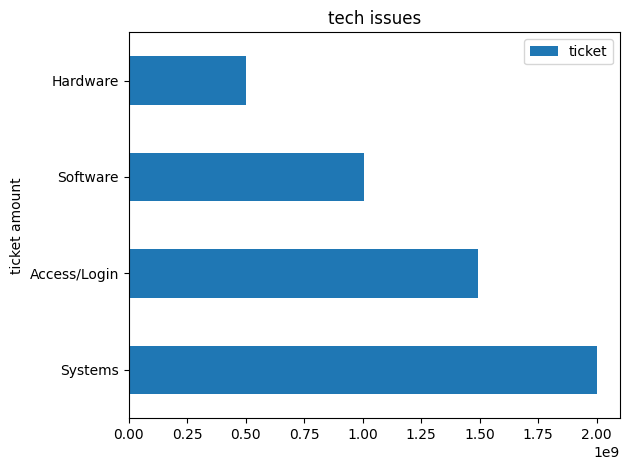

In [8]:
ax = df_quantity_filedagainst.plot(
    kind= "barh",
    y="ticket",
    title="tech issues",
    ylabel="ticket amount"
)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("filedagainst_bargraph_1stedition.png")

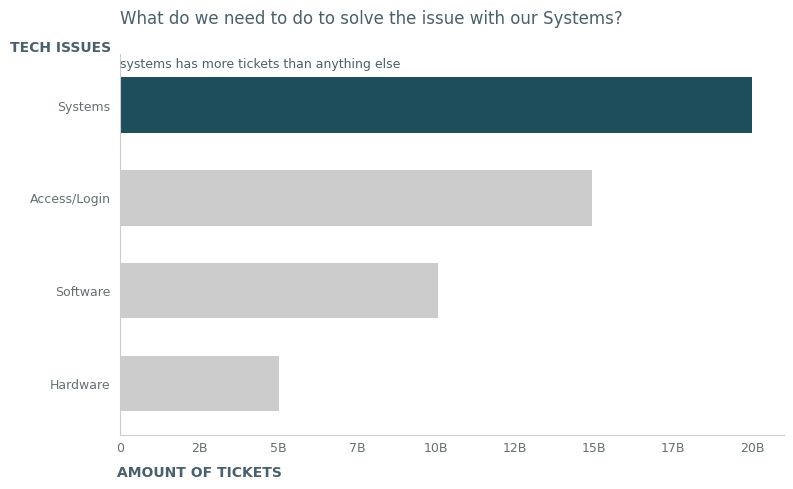

In [9]:
colors = [GRAY_1] * len(df_quantity_filedagainst)
colors[0] = BLUE_1

ax = df_quantity_filedagainst.plot(
    kind= "barh",
    y="ticket",
    figsize=(8, 5),
    width=0.6,
    color=colors
)

#remove clutter
ax.legend().remove()
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

#better contrast
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_2, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

#descriptive labels and title
ax.set_xlabel("AMOUNT OF TICKETS", color=GRAY_3, fontweight="bold")
ax.set_ylabel("TECH ISSUES", rotation=0, color=GRAY_3, fontweight="bold")

ax.set_title("What do we need to do to solve the issue with our Systems?",
             pad=22,
             color=GRAY_3,
             loc="left"
             )

#annotations and fixed label postitions
ax.xaxis.set_label_coords(0.12, -0.08)
ax.yaxis.set_label_coords(-0.09, 1)

ax.annotate(
    xy=(1,-0.4),
    text=("systems has more tickets than anything else"),
    fontsize=9,
    color=GRAY_3
)
ax = billions_formatter(ax)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("filedagainst_bargraph_3rdedition.png", dpi=250)

In [36]:
df_quantity_satisfaction = duckdb.query("""
SELECT 
        Satisfation AS satisfaction,
        SUM(ticket) as ticket
FROM
        df
GROUP BY 
        satisfaction
ORDER BY
        ticket DESC
""").df().set_index("satisfaction")
df_quantity_satisfaction.head()

,ticket
satisfaction,
Unknown,1.500620e+09
Highly satisfied,1.455629e+09
Unsatisfied,1.056896e+09
Satisfied,9.869047e+08


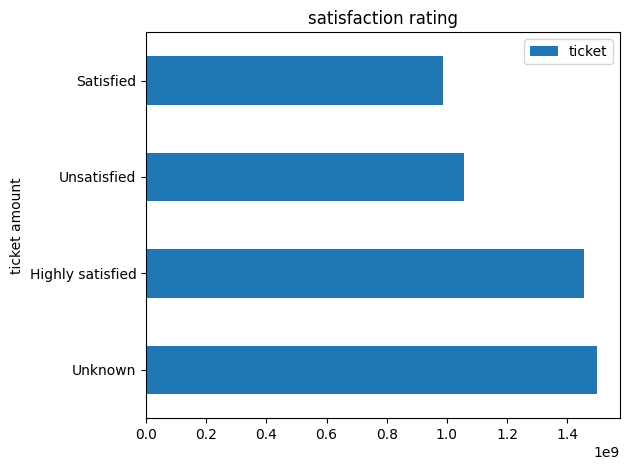

In [37]:
ax = df_quantity_satisfaction.plot(
    kind= "barh",
    y="ticket",
    title="satisfaction rating",
    ylabel="ticket amount"
)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("satisfaction_bargraph_1stedition.png")

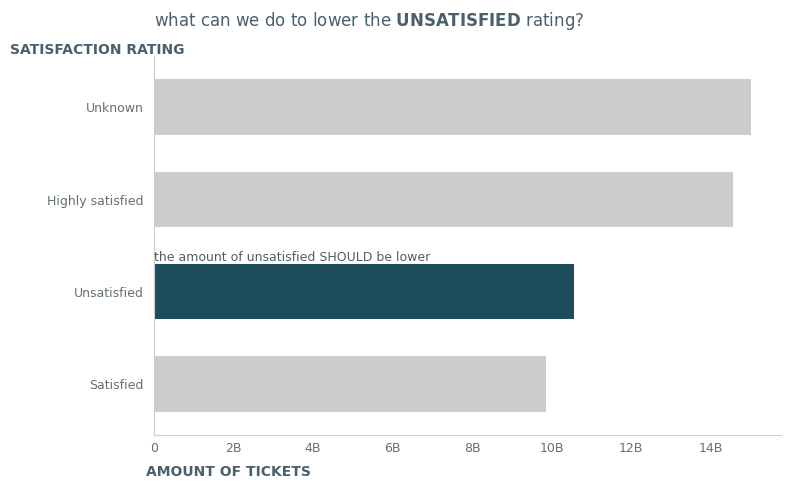

In [57]:
colors = [GRAY_1] * len(df_quantity_satisfaction)
colors[2] = BLUE_1

ax = df_quantity_satisfaction.plot(
    kind= "barh",
    y="ticket",
    figsize=(8, 5),
    width=0.6,
    color=colors
)

#remove clutter
ax.legend().remove()
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

#better contrast
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_2, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

#descriptive labels and title
ax.set_xlabel("AMOUNT OF TICKETS", color=GRAY_3, fontweight="bold")
ax.set_ylabel("SATISFACTION RATING", rotation=0, color=GRAY_3, fontweight="bold")

ax.set_title(
    r"what can we do to lower the"
    + r" $\bf{UNSATISFIED}$"
    + " rating?",
    pad=22,
    color=GRAY_3,
    loc="left"
    )

#annotations and fixed label postitions
ax.xaxis.set_label_coords(0.12, -0.08)
ax.yaxis.set_label_coords(-0.09, 1)

ax.annotate(
    xy=(1,1.66),
    text=("the amount of unsatisfied SHOULD be lower"),
    fontsize=9,
    color=GRAY_3
)
ax = billions_formatter(ax)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("satisfaction_bargraph_2ndedition.png")